#### Name: Mason Miller

# PHYS 230 Lab Assignment 14

### Monday, March 30, 2026: Chapter 8.1
- First-order differential equations 

In [33]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt

### The problem:

Today we will solve a first-order ordinary differential equation for the velocity of a falling ball with air resistance (assuming linear drag). This equation, assuming vertical motion only and downwards as the positive y-direction, is given as: 

$$\frac{dv}{dt}= g -\frac{b}{m}v $$

The exact solution to this differential equation is: 

$$ v(t) = v_0 e^{-\frac{b}{m}t} + v_{\text{ter}} \left( 1 -  e^{-\frac{b}{m}t} \right) $$


where $v_0$ is the initial velocity and $v_{\text{ter}} = \frac{mg}{b}$ is the terminal velocity. For this problem, we will assume that our 1.0 kg ball is initially at rest, so $v_0 = 0$ at $t=0$, the graviational acceleration $g = 9.8 \text{ m/s}^2$, and the drag coefficient $b = 0.1 \frac{\text{N}}{\text{m/s}}$. 

*don't forget comments in your code cells*

### Part 1: Exact Solution

Calculate the exact solution of $v(t)$ for an array of times. Do this in the following steps: 

#### Step 1: 

Write a function `v(t,b,m,v0)` that takes in an array of times (from $t=0$ to $t=100$ by 2's) and constants $b,m,v_0$ and returns an array of velocities using the equation above. Think about any constants might need to be included inside the function. 

In [34]:
# define the function

def v(t,b,m,v0):
    g = 9.8  #acceleration due to grabity to calculate vter
    v_ter = (m * g) / b
    return v0 * np.exp(-(b/m) * t) + v_ter * (1 - np.exp(-(b/m) * t))

### <font color='purple'> Comments </font> 

<font color='purple'> nice job with including appropriate constnats and other calculations  </font> 


#### Step 2: 

Define the array of times $t$, or whatever variable you want to use, and your necessary constants, and calculate the array of velocities using your function. 

In [35]:
t = np.arange(0,101,2)
# defien the variables
b = 0.1
m = 1.0
v0 = 0.0

velocities = v(t,b,m,v0)
print(velocities)

[ 0.         17.7643862  32.30863549 44.21645966 53.96576152 61.94781477
 68.48296723 73.83349753 78.21414124 81.80070895 84.73714224 87.14129048
 89.10964058 90.72118933 92.04061386 93.1208673  94.00530401 94.72941954
 95.3222752  95.80766436 96.20506739 96.53043347 96.79682069 97.0149201
 97.19348479 97.33968119 97.45937669 97.55737507 97.63760936 97.70329963
 97.75708229 97.8011158  97.83716739 97.86668393 97.89085004 97.91063557
 97.92683459 97.94009723 97.95095576 97.95984597 97.96712466 97.97308395
 97.977963   97.98195763 97.98522816 97.98790584 97.99009814 97.99189304
 97.99336258 97.99456574 97.99555081]


#### Step 3: 
Make a plot of the results. 

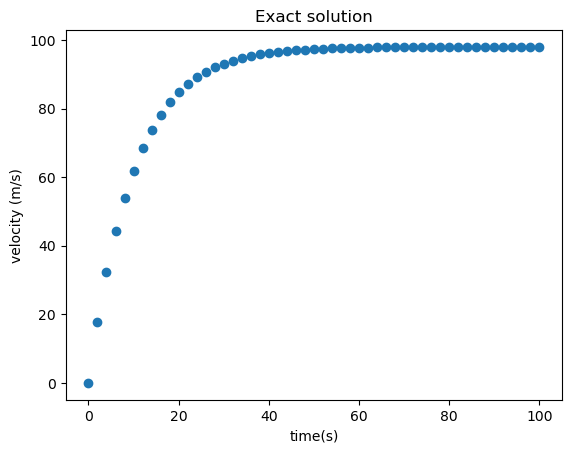

In [36]:
plt.plot(t, velocities, 'o') #plot statement
plt.xlabel('time(s)')
plt.ylabel('velocity (m/s)')
plt.title('Exact solution')
plt.show()

### <font color='purple'> Comments </font> 

<font color='purple'> excellent! </font> 


### Part 2: Euler Method

Calculate the solution for the same array of times using the Euler method instead. 

#### Step 1: 

Write two functions: `f(v)` that calculate the result of the differential equation for vertical, linear projectile motion, and `euler(t,h,v0,f)` that takes in an array $t$ of times in the same range as part 1 and using a defined $h$ value,initial conditions, and the differential equation returns an *array*. 

In [37]:
# define the two functions
def f(v): #differential
    g = 9.8
    return g - (b/m)*v

def euler(t,h,v0,f): #eulers
    v = np.zeros(len(t))
    x = v0 #variable to act as current velocity
    for i in range(len(t)):
        v[i] = x #given velocity in the zero array gets the x variable
        x += h * f(x) #step times differential assigned to x
    return v

### <font color='purple'> Comments </font> 

<font color='purple'> great commenting and leaving of white space </font> 


#### Step 2

Calculate the array of velocities usig your `euler` function and make a plot of the results with the exact calculation on the **same** graph (put both results on the same graph here).

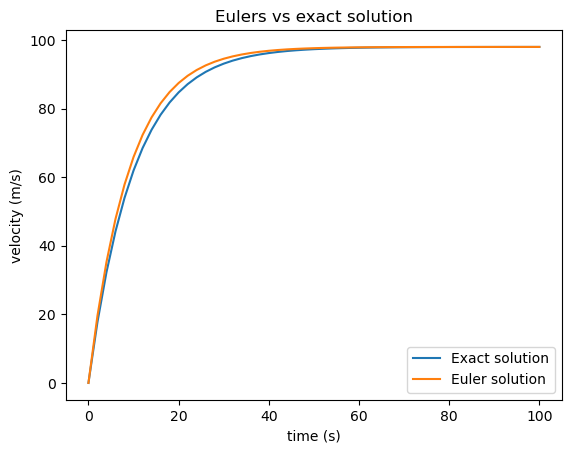

In [40]:
# define h first
N = 50 #number of steps
h = 100/N # 100 comes from the length of the time array

# calculate velocities using euler function
euler_v = euler(t,h,v0,f)

# plot euler and exact on the same graph
plt.plot(t, velocities, label='Exact solution')
plt.plot(t, euler_v, label="Euler solution")
plt.xlabel('time (s)')
plt.ylabel('velocity (m/s)')
plt.title("Eulers vs exact solution")
plt.legend()
plt.show()



### <font color='purple'> Comments </font> 

<font color='purple'> this is very well done, but shoudl make points instead of connnected lines. I want to see the accuracy of your result based on the number of points you used and connected lines can kind of fill that in  </font> 


### Part 3: Fourth-order Runge-Kutta Method

Calculate the solution for the same array of times using the Runge-Kutta method instead. For this, define a function `RK4(t,h,v0,f)` that takes in an array of times, initial velocity, $h$, initial conditions, and differential equation function. 

Plot this as well as the exact and Euler solutions on the **same** graph as well. 

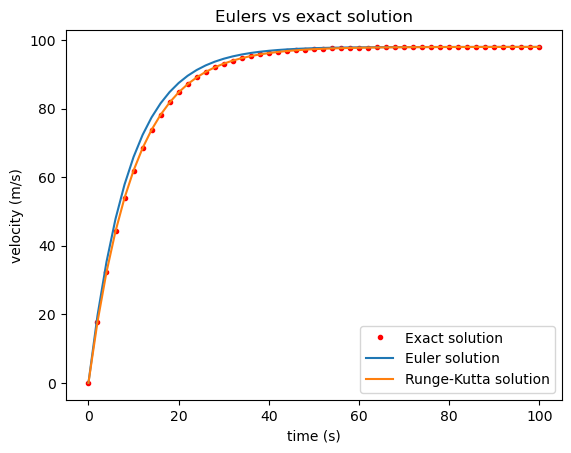

In [46]:
# define the function
# the diff eq f is defined above
def RK4(t,h,v0,f):
    v = np.zeros(len(t))
    x = v0 # same as last problem, let x be the variable that increases
    for i in range(len(t)):
        v[i] = x #given velocity in the zero array gets the x variable
        # calculate k1 through k4, easier here since our diff eq has only one variable
        k1 = h * f(x)
        k2 = h * f(x + 0.5*k1)
        k3 = h * f(x + 0.5*k2)
        k4 = h * f(x + k3)
        x += (k1 + 2*k2 + 2*k3 + k4) / 6
    return v

# create array of rk4 velocities to plot
RK4_v = RK4(t,h,v0,f)

plt.plot(t, velocities, '.r', label='Exact solution' )
plt.plot(t, euler_v, label='Euler solution')
plt.plot(t, RK4_v, label='Runge-Kutta solution')
plt.xlabel('time (s)')
plt.ylabel('velocity (m/s)')
plt.title("Eulers vs exact solution")
plt.legend()
plt.show()


### <font color='purple'> Comments </font> 

<font color='purple'> lovely! your commenting is exquisite. just need to have points instead of connected lines </font> 


### Part 4: Markdown comparision

What can you conclude about the results? Do they all agree? (Explain in a markdown cell below - you will need to change it to a markdown cell first)

The results agree well ish! The euler solution overestimates the velocities slightly, but the Runge kutta method is a really great approximation; it almost exactly matches the exact solution.

### Part 5: Adjust

Try using smaller and bigger time steps to see the effect of improving your approximations (Euler and/or Runge-Kutta). Explain your results and process in markdown. 

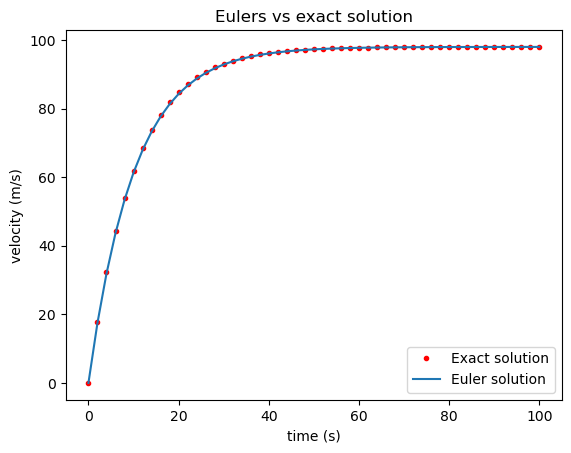

In [56]:
# pasting the steps part and the part where I calculate the euler velocity array
# from here i will tinker with the step size and plot

N = 56 #number of steps
h = 100/N # 100 comes from the length of the time array

# calculate velocities using euler function
euler_v_new = euler(t,h,v0,f)

# plot
plt.plot(t, velocities, '.r', label='Exact solution' )
plt.plot(t, euler_v_new, label='Euler solution')
# plt.plot(t, RK4_v, label='Runge-Kutta solution')
plt.xlabel('time (s)')
plt.ylabel('velocity (m/s)')
plt.title("Eulers vs exact solution")
plt.legend()
plt.show()

#### Explanation Markdown Cell: 

I only tried to improve the euler approximation, as the runge kutta was so close already. I decreased the step size and found that the euler solution overestimated further. I increased the step size and found that it underestimated. The happy-medium fro step size ended up being 100/56, or roughly 1.79. This is different than the original step size of 2.

### <font color='purple'> Comments </font> 

<font color='purple'>where are the results of your increased step size? shoudl really show both  </font> 
